In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.datasets import get_rdataset 
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler 
from ISLP import load_data

from sklearn.cluster import (KMeans, AgglomerativeClustering)
from scipy.cluster.hierarchy import (dendrogram , cut_tree)
from ISLP.cluster import compute_linkage

### Data Cleaning

In [4]:
itemdf = pd.read_csv("../datasets/olist_order_items_joined.csv")
itemdf 

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,...,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_score,total_payment,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,00010242fe8c5a6d1ba2dd792cb16214,1.0,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,...,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29 00:00:00,5.0,72.19,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ
1,00018f77f2f0320c557190d7a144bdd3,1.0,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,...,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15 00:00:00,4.0,259.83,eb28e67c4c0b83846050ddfb8a35d051,15775,santa fe do sul,SP
2,000229ec398224ef6ca0657da4fc703e,1.0,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,...,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05 00:00:00,5.0,216.87,3818d81c6709e39d06b2738a8d3a2474,35661,para de minas,MG
3,00024acbcdf0a6daa1e931b038114c75,1.0,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,...,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20 00:00:00,4.0,25.78,af861d436cfc08b2c2ddefd0ba074622,12952,atibaia,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,1.0,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,...,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17 00:00:00,5.0,218.04,64b576fb70d441e8f1b2d7d446e483c5,13226,varzea paulista,SP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113420,fffc94f6ce00a00581880bf54a75a037,1.0,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41,utilidades_domesticas,43.0,1002.0,...,2018-04-25 04:11:01,2018-04-25 12:09:00,2018-05-10 22:56:40,2018-05-18 00:00:00,5.0,343.40,0c9aeda10a71f369396d0c04dce13a64,65077,sao luis,MA
113421,fffcd46ef2263f404302a634eb57f7eb,1.0,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53,informatica_acessorios,31.0,232.0,...,2018-07-17 04:31:48,2018-07-17 08:05:00,2018-07-23 20:31:55,2018-08-01 00:00:00,5.0,386.53,0da9fe112eae0c74d3ba1fe16de0988b,81690,curitiba,PR
113422,fffce4705a9662cd70adb13d4a31832d,1.0,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95,esporte_lazer,43.0,869.0,...,2017-10-24 17:14:25,2017-10-26 15:13:14,2017-10-28 12:22:22,2017-11-10 00:00:00,5.0,116.85,cd79b407828f02fdbba457111c38e4c4,4039,sao paulo,SP
113423,fffe18544ffabc95dfada21779c9644f,1.0,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72,informatica_acessorios,56.0,1306.0,...,2017-08-15 00:04:32,2017-08-15 19:02:53,2017-08-16 21:59:40,2017-08-25 00:00:00,5.0,64.71,eb803377c9315b564bdedad672039306,13289,vinhedo,SP


In [7]:
itemdf = itemdf.dropna()

In [9]:
itemdf.info()

<class 'pandas.core.frame.DataFrame'>
Index: 107825 entries, 0 to 113424
Data columns (total 31 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       107825 non-null  object 
 1   order_item_id                  107825 non-null  float64
 2   product_id                     107825 non-null  object 
 3   seller_id                      107825 non-null  object 
 4   shipping_limit_date            107825 non-null  object 
 5   price                          107825 non-null  float64
 6   freight_value                  107825 non-null  float64
 7   product_category_name          107825 non-null  object 
 8   product_name_lenght            107825 non-null  float64
 9   product_description_lenght     107825 non-null  float64
 10  product_photos_qty             107825 non-null  float64
 11  product_weight_g               107825 non-null  float64
 12  product_length_cm              1078

### Aggregating the data by unique customer ID

In [9]:
# Aggregate customer data
customer_data = itemdf.groupby('customer_unique_id').agg({
    'price': 'sum',                     # Total spending
    'freight_value': 'sum',             # Total freight cost
    'order_id': 'count',                # Total orders (frequency)
    'product_id': 'nunique',            # Unique products purchased
    'product_category_name': 'nunique' # Unique categories purchased
}).reset_index()

# Rename columns for clarity
customer_data.columns = ['customer_id', 'total_spent', 'total_freight', 'order_count', 'unique_products', 'unique_categories']

customer_data.head()

,customer_id,total_spent,total_freight,order_count,unique_products,unique_categories
0,0000366f3b9a7992bf8c76cfdf3221e2,129.90,12.00,1,1,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,18.90,8.29,1,1,1
2,0000f46a3911fa3c0805444483337064,69.00,17.22,1,1,1
3,0000f6ccb0745a6a4b88665a16c9f078,25.99,17.63,1,1,1
4,0004aac84e0df4da2b147fca70cf8255,180.00,16.89,1,1,1


In [15]:
customer_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91484 entries, 0 to 91483
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        91484 non-null  object 
 1   total_spent        91484 non-null  float64
 2   total_freight      91484 non-null  float64
 3   order_count        91484 non-null  int64  
 4   unique_products    91484 non-null  int64  
 5   unique_categories  91484 non-null  int64  
dtypes: float64(2), int64(3), object(1)
memory usage: 4.2+ MB


In [17]:
#customer_samp = customer_data.sample(frac=0.2, random_state=3)

In [33]:
#customer_samp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18297 entries, 28179 to 53192
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        18297 non-null  object 
 1   total_spent        18297 non-null  float64
 2   total_freight      18297 non-null  float64
 3   order_count        18297 non-null  int64  
 4   unique_products    18297 non-null  int64  
 5   unique_categories  18297 non-null  int64  
dtypes: float64(2), int64(3), object(1)
memory usage: 1000.6+ KB


### Scaling data 

In [11]:
# Select features for clustering
features = customer_data[['total_spent', 'total_freight', 'order_count', 'unique_products', 'unique_categories']]

# Scale the features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

### Determining number of clusters - elbow method 

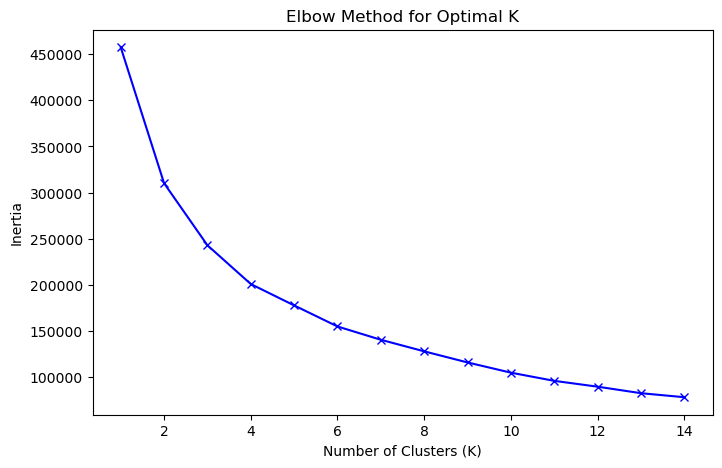

In [38]:
# Elbow Method
distortions = []
K = range(1, 15)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    distortions.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(K, distortions, 'bx-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.show()

at 4 is where the inertia  starts decreasing more slowly but i am going to chose 5 as the number of clusters to ensure that the clusters are not too broad 

### K mean Clustering: K = 5

In [13]:
# Perform K-Means clustering with K=5
kmeans = KMeans(n_clusters=5, random_state=10, n_init=20)
customer_data['Cluster'] = kmeans.fit_predict(scaled_features)

# Display a sample of the data with cluster assignments
customer_data.head()

,customer_id,total_spent,total_freight,order_count,unique_products,unique_categories,Cluster
0,0000366f3b9a7992bf8c76cfdf3221e2,129.90,12.00,1,1,1,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,18.90,8.29,1,1,1,0
2,0000f46a3911fa3c0805444483337064,69.00,17.22,1,1,1,0
3,0000f6ccb0745a6a4b88665a16c9f078,25.99,17.63,1,1,1,0
4,0004aac84e0df4da2b147fca70cf8255,180.00,16.89,1,1,1,0


In [14]:
numeric_columns = customer_data.select_dtypes(include=['float64', 'int64']).columns

# Analyze cluster characteristics
cluster_summary = customer_data.groupby('Cluster')[numeric_columns].agg(['mean', 'median', 'std', 'min', 'max', 'count'])

# Display the cluster summary
cluster_summary

total_spent                                               \
                mean   median         std     min      max  count   
Cluster                                                             
0          89.833669    69.90   68.614340    0.85    494.0  71806   
1         282.823086   209.99  214.734465    7.80   1109.0  12887   
2         207.327486   158.56  175.223148   14.00   2000.0   3524   
3         238.667192   179.80  204.066866   20.25   1835.0   2133   
4        1411.669418  1260.00  816.385977  139.98  13440.0   1134   

        total_freight                             ... unique_products          \
                 mean  median         std    min  ...             std min max   
Cluster                                           ...                           
0           16.648896  15.790    6.247614   0.00  ...        0.000000   1   1   
1           44.432514  39.340   22.648122   0.00  ...        0.000000   1   1   
2           46.987270  36.590   31.137604   0.00  ...        0.645883   1   8   
3           48.028059  37.710   32.817992  11.85  ...        0.710184   2  13   
4          104.175450  70.845  105.795509  15.58  ...        0.289617   1   6   

               unique_categories                                  
         count              mean median       std min max  count  
Cluster                                                           
0        71806          1.000000    1.0  0.000000   1   1  71806  
1        12887          1.000000    1.0  0.000000   1   1  12887  
2         3524          1.000000    1.0  0.000000   1   1   3524  
3         2133          2.066573    2.0  0.294211   2   5   2133  
4         1134          1.006173    1.0  0.078359   1   2   1134  

[5 rows x 30 columns]

In [144]:
# Export cluster_summary to a CSV file
output_csv_path = "cluster_summary.csv"
cluster_summary.to_csv(output_csv_path)
print(f"Cluster summary exported to {output_csv_path}")

Cluster summary exported to cluster_summary.csv


In [17]:
total_spent = customer_data.groupby('Cluster')["total_spent"]
total_spent_summary = total_spent.describe(include="all")
total_spent_summary

,count,mean,std,min,25%,50%,75%,max
Cluster,,,,,,,,
0,71806.0,89.833669,68.614340,0.85,39.90,69.90,119.9000,494.0
1,12887.0,282.823086,214.734465,7.80,119.98,209.99,389.9000,1109.0
2,3524.0,207.327486,175.223148,14.00,94.80,158.56,259.9575,2000.0
3,2133.0,238.667192,204.066866,20.25,114.39,179.80,288.9000,1835.0
4,1134.0,1411.669418,816.385977,139.98,990.00,1260.00,1659.7075,13440.0


In [30]:
import seaborn as sns

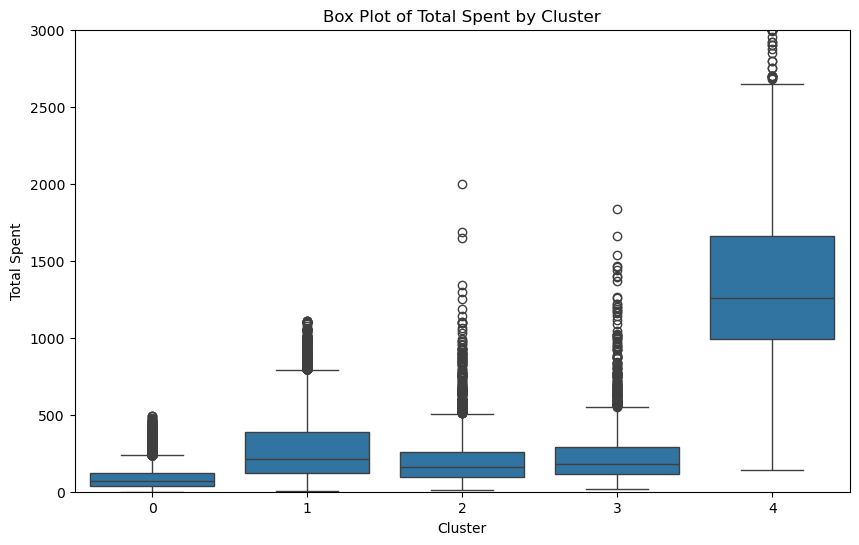

In [34]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Cluster', y='total_spent', data=customer_data)
plt.title('Box Plot of Total Spent by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Total Spent')
plt.ylim(0, 3000)  
plt.show()

In [21]:
total_freight = customer_data.groupby('Cluster')["total_freight"]
total_freight_summary = total_freight.describe(include="all")
total_freight_summary

,count,mean,std,min,25%,50%,75%,max
Cluster,,,,,,,,
0,71806.0,16.648896,6.247614,0.00,12.900,15.790,19.0000,44.85
1,12887.0,44.432514,22.648122,0.00,29.040,39.340,53.2750,215.43
2,3524.0,46.987270,31.137604,0.00,28.815,36.590,55.7225,357.48
3,2133.0,48.028059,32.817992,11.85,29.690,37.710,56.2300,345.86
4,1134.0,104.175450,105.795509,15.58,39.485,70.845,141.6275,1794.96


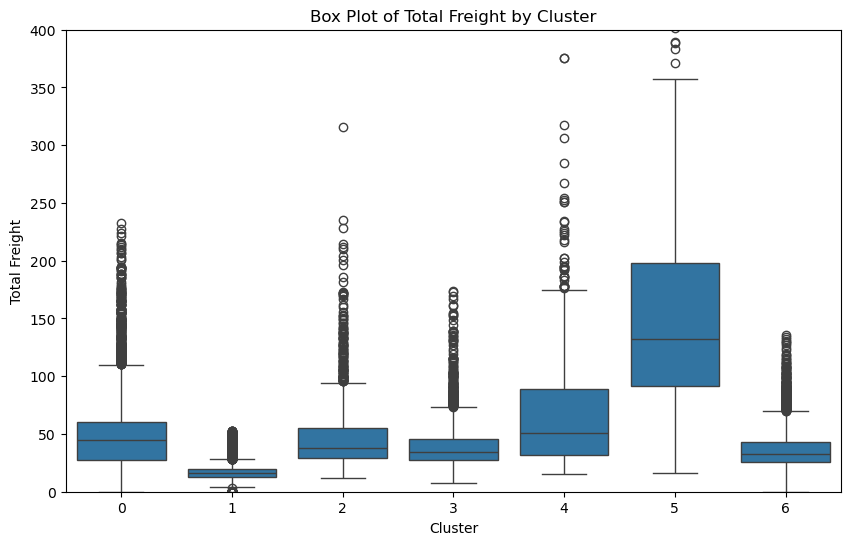

In [126]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Cluster', y='total_freight', data=customer_data)
plt.title('Box Plot of Total Freight by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Total Freight')
plt.ylim(0, 400) # adjust axis to eliminate distortion casued by outlier 
plt.show()

In [23]:
unique_products = customer_data.groupby('Cluster')["unique_products"]
unique_products_summary = unique_products.describe(include="all")
unique_products_summary

,count,mean,std,min,25%,50%,75%,max
Cluster,,,,,,,,
0,71806.0,1.000000,0.000000,1.0,1.0,1.0,1.0,1.0
1,12887.0,1.000000,0.000000,1.0,1.0,1.0,1.0,1.0
2,3524.0,1.990352,0.645883,1.0,2.0,2.0,2.0,8.0
3,2133.0,2.247539,0.710184,2.0,2.0,2.0,2.0,13.0
4,1134.0,1.051146,0.289617,1.0,1.0,1.0,1.0,6.0


In [25]:
order_count = customer_data.groupby('Cluster')["order_count"]
order_count_summary = order_count.describe(include="all")
order_count_summary

,count,mean,std,min,25%,50%,75%,max
Cluster,,,,,,,,
0,71806.0,1.011239,0.105416,1.0,1.0,1.0,1.0,2.0
1,12887.0,1.412354,0.599210,1.0,1.0,1.0,2.0,3.0
2,3524.0,2.787174,1.465119,2.0,2.0,2.0,3.0,21.0
3,2133.0,2.509142,1.120145,2.0,2.0,2.0,3.0,14.0
4,1134.0,1.619929,1.634035,1.0,1.0,1.0,1.0,24.0


In [27]:
# exporting spending and freight tables 

total_spent_summary.to_csv("total_spent_summary.csv")
total_freight_summary.to_csv("total_freight_summary.csv")
unique_products_summary.to_csv("unique_products_summary.csv")
order_count_summary.to_csv("order_count_summary.csv")

#### Visualizing cluster k5

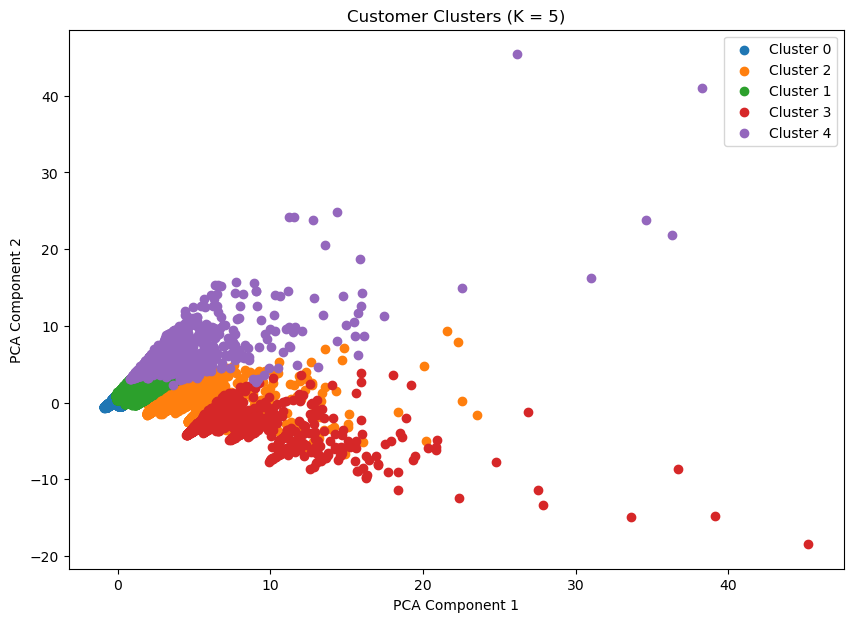

In [44]:
# Step 1: Perform PCA to reduce the data to 2 dimensions
pca = PCA(n_components=2)
pca_features = pca.fit_transform(scaled_features)

# Step 2: Create a scatter plot of the clusters
plt.figure(figsize=(10, 7))
for cluster_id in customer_data['Cluster'].unique():
    cluster_points = pca_features[customer_data['Cluster'] == cluster_id]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f'Cluster {cluster_id}')

# Step 3: Add labels and legend
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Customer Clusters (K = 5)')
plt.legend()
plt.show()

In [46]:
cluster_inertia = kmeans.inertia_
print(cluster_inertia)

177903.07988465892


### Kmean Cluster with 7

In [170]:
kmeans7 = KMeans(n_clusters=7, random_state=10, n_init=20)
customer_data['Cluster7'] = kmeans7.fit_predict(scaled_features)

cluster_summary7 = customer_data.groupby('Cluster7')[numeric_columns].agg(['mean', 'median', 'std', 'min', 'max', 'count'])
cluster_summary7

total_spent                                                \
                 mean   median         std     min       max  count   
Cluster7                                                              
0          374.899605   329.90  225.817368   18.90   1029.99   7772   
1           90.416752    69.99   68.266257    0.85    460.00  71898   
2          236.417323   179.80  202.419565   20.25   1684.29   2114   
3          189.693782   148.00  151.296807   14.00   1686.90   2903   
4         1602.718347  1360.00  817.500985  799.99  13440.00    859   
5          568.474371   451.20  468.426061   17.50   4080.00    485   
6          150.092443   119.50  117.011218    7.80   1056.00   5453   

         total_freight                              ... unique_products      \
                  mean   median         std    min  ...             std min   
Cluster7                                            ...                       
0            49.689770   45.130   29.027400   0.00  ...        0.000000   1   
1            16.961883   15.870    6.841664   0.00  ...        0.000000   1   
2            46.593382   37.435   28.494098  11.85  ...        0.706938   2   
3            39.264781   34.110   20.370717   7.39  ...        0.504650   2   
4            67.268056   50.430   51.078836  15.46  ...        0.210868   1   
5           164.750639  132.380  130.529602  16.17  ...        0.856178   1   
6            36.377886   32.360   17.308125   0.00  ...        0.000000   1   

                    unique_categories                                  
         max  count              mean median       std min max  count  
Cluster7                                                               
0          1   7772          1.000000    1.0  0.000000   1   1   7772  
1          1  71898          1.000000    1.0  0.000000   1   1  71898  
2         13   2114          2.066698    2.0  0.294769   2   5   2114  
3          8   2903          1.000000    1.0  0.000000   1   1   2903  
4          5    859          1.002328    1.0  0.048224   1   2    859  
5          7    485          1.051546    1.0  0.230483   1   3    485  
6          1   5453          1.000000    1.0  0.000000   1   1   5453  

[7 rows x 30 columns]

In [160]:
# Export cluster_summary to a CSV file
output_csv_pathK7 = "cluster_summaryK7.csv"
cluster_summary7.to_csv(output_csv_pathK7)
print(f"Cluster summary exported to {output_csv_pathK7}")

Cluster summary exported to cluster_summaryK7.csv


In [172]:
total_spent7 = customer_data.groupby('Cluster7')["total_spent"]
total_spent7_summary = total_spent7.describe(include="all")
total_spent7_summary

,count,mean,std,min,25%,50%,75%,max
Cluster7,,,,,,,,
0,7772.0,374.899605,225.817368,18.90,189.000,329.90,527.900,1029.99
1,71898.0,90.416752,68.266257,0.85,39.900,69.99,119.990,460.00
2,2114.0,236.417323,202.419565,20.25,113.825,179.80,285.775,1684.29
3,2903.0,189.693782,151.296807,14.00,89.990,148.00,238.945,1686.90
4,859.0,1602.718347,817.500985,799.99,1180.000,1360.00,1799.000,13440.00
5,485.0,568.474371,468.426061,17.50,230.400,451.20,796.000,4080.00
6,5453.0,150.092443,117.011218,7.80,70.000,119.50,198.000,1056.00


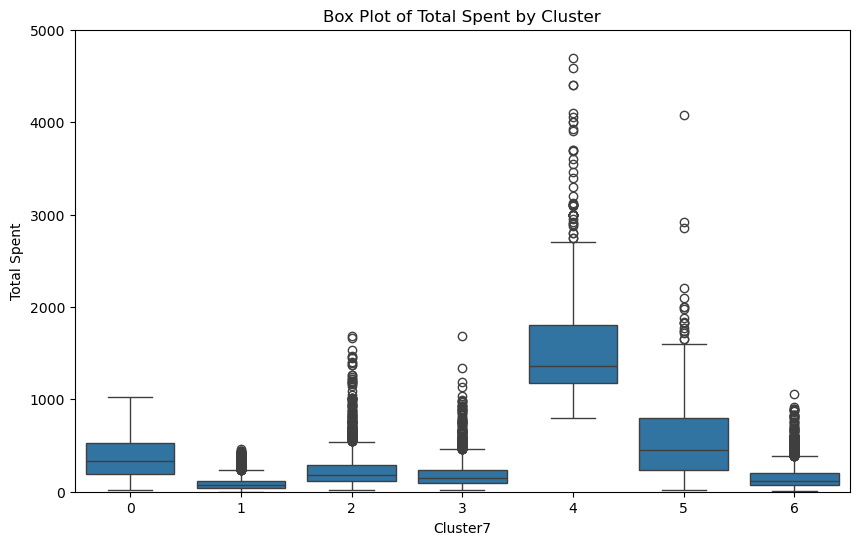

In [115]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Cluster7', y='total_spent', data=customer_data)
plt.title('Box Plot of Total Spent by Cluster')
plt.xlabel('Cluster7')
plt.ylabel('Total Spent')
plt.ylim(0, 5000)  # Adjust the upper limit as needed (e.g., 2000)
plt.show()

In [174]:
total_freight7 = customer_data.groupby('Cluster7')["total_freight"]
total_freight7_summary = total_freight7.describe(include="all")
total_freight7_summary

,count,mean,std,min,25%,50%,75%,max
Cluster7,,,,,,,,
0,7772.0,49.689770,29.027400,0.00,27.760,45.130,60.7750,232.69
1,71898.0,16.961883,6.841664,0.00,12.920,15.870,19.2500,52.95
2,2114.0,46.593382,28.494098,11.85,29.605,37.435,55.4975,316.11
3,2903.0,39.264781,20.370717,7.39,27.275,34.110,45.7550,173.47
4,859.0,67.268056,51.078836,15.46,31.510,50.430,89.1800,375.28
5,485.0,164.750639,130.529602,16.17,91.150,132.380,198.4000,1794.96
6,5453.0,36.377886,17.308125,0.00,25.700,32.360,43.4200,135.27


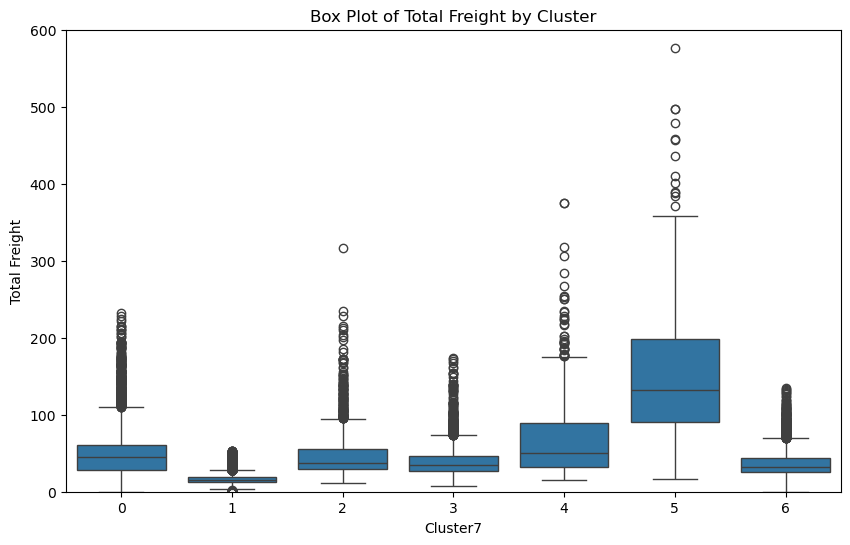

In [120]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Cluster7', y='total_freight', data=customer_data)
plt.title('Box Plot of Total Freight by Cluster')
plt.xlabel('Cluster7')
plt.ylabel('Total Freight')
plt.ylim(0, 600)
plt.show()

In [176]:
total_spent7_summary.to_csv("total_spent_summaryK7.csv")
total_freight7_summary.to_csv("total_freight_summaryK7.csv")

#### Visualizing the clusters 

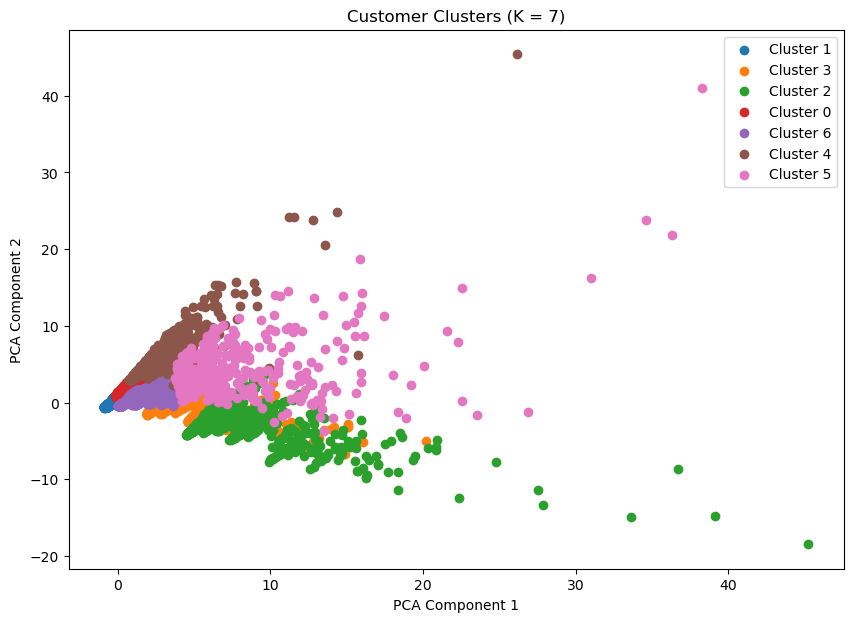

In [50]:
plt.figure(figsize=(10, 7))
for cluster_id in customer_data['Cluster7'].unique():
    cluster_points = pca_features[customer_data['Cluster7'] == cluster_id]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f'Cluster {cluster_id}')

# Step 3: Add plot labels and legend
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Customer Clusters (K = 7)')
plt.legend()
plt.show()

In [52]:
cluster_inertia7 = kmeans7.inertia_
print(cluster_inertia7)

139067.70306905135


### Hierarchical Clustering

In [64]:
# features were already scaled in previous steps 

# Step 2: Hierarchical Clustering with Complete Linkage
hc_comp = AgglomerativeClustering(compute_distances=True, distance_threshold=0, n_clusters=None, linkage='complete')
hc_comp.fit(scaled_features)

AgglomerativeClustering(compute_distances=True, distance_threshold=0,
                        linkage='complete', n_clusters=None)

In [66]:
# Step 3: Create Linkage Matrix for the Dendrogram (custom computation)
def compute_linkage(model):
    n_samples = len(model.labels_)
    counts = np.zeros(model.children_.shape[0])
    for i, merge in enumerate(model.children_):
        counts[i] = counts[i] + (merge < n_samples).sum()
    linkage_matrix = np.column_stack([model.children_, model.distances_, counts]).astype(float)
    return linkage_matrix

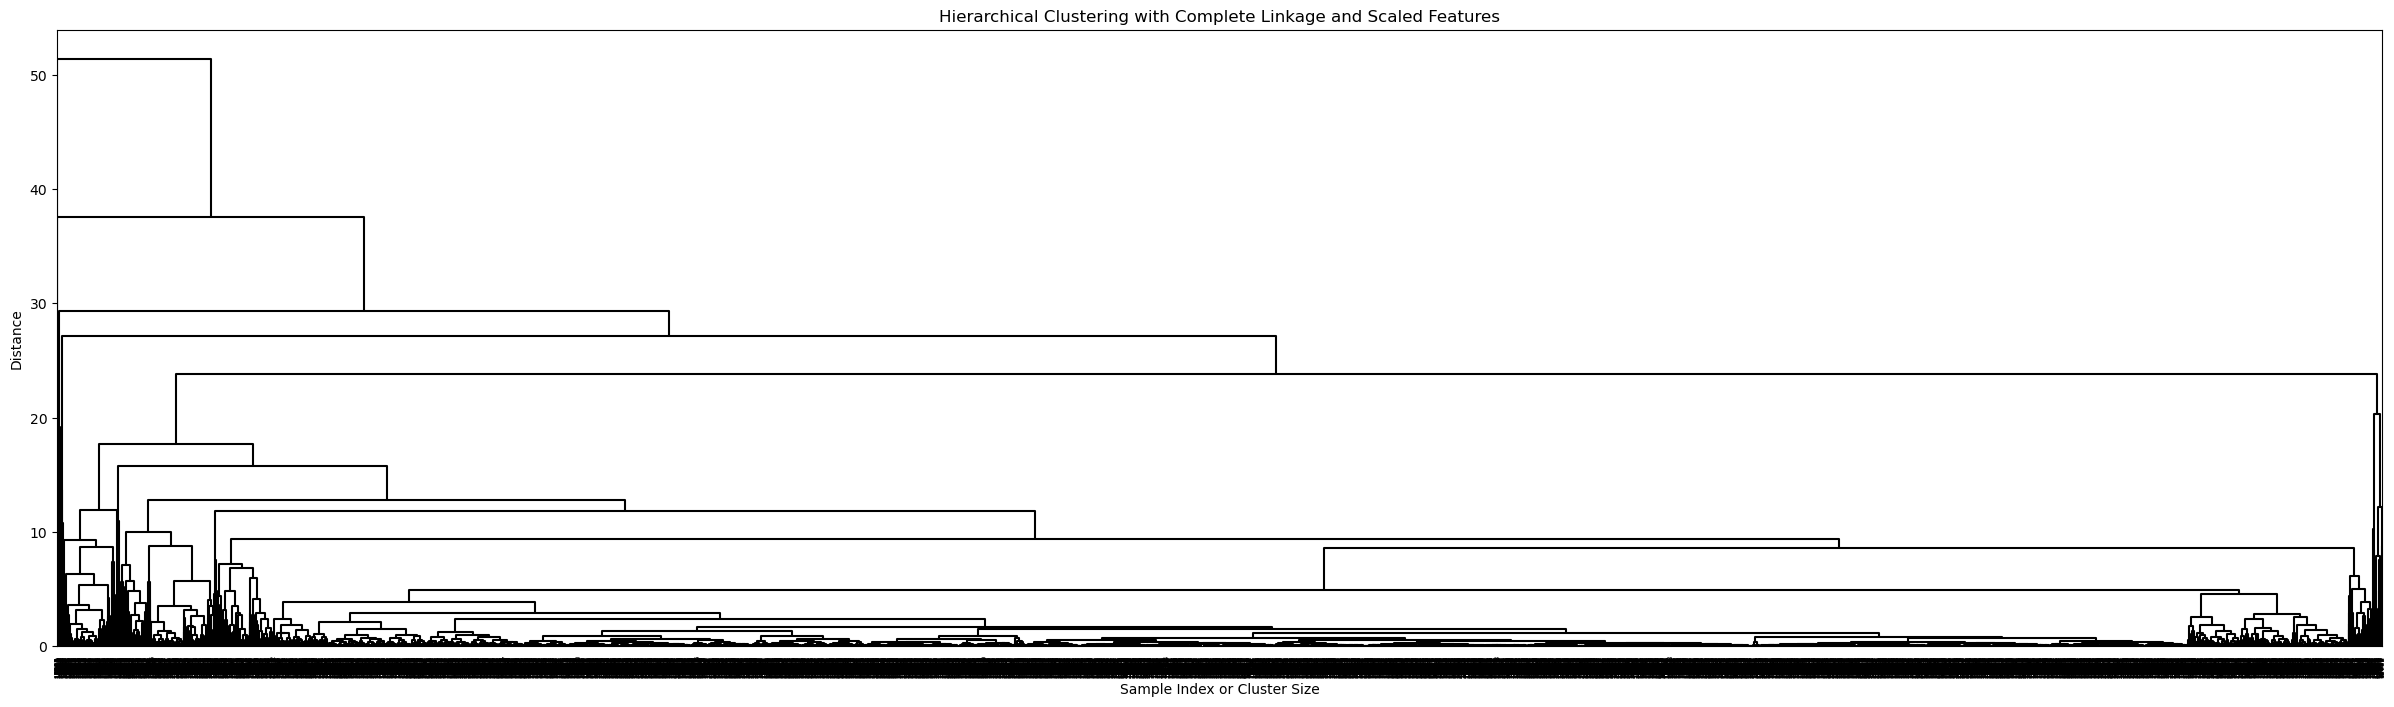

In [72]:
# Step 4: Compute the Linkage Matrix and Plot the Dendrogram
linkage_comp = compute_linkage(hc_comp)
fig, ax = plt.subplots(1, 1, figsize=(30, 8))
dendrogram(linkage_comp, ax=ax, color_threshold=0, above_threshold_color='black')
ax.set_title("Hierarchical Clustering with Complete Linkage and Scaled Features")
ax.set_xlabel("Sample Index or Cluster Size")
ax.set_ylabel("Distance")
plt.show()

In [ ]:
# Step 5: Assign Clusters from a Dendrogram Cut (e.g., 5 clusters)
n_clusters = 5
cluster_labels = cut_tree(linkage_comp, n_clusters=n_clusters).flatten()

# Add the cluster labels to the dataset
customer_data['Cluster_Hierarchical'] = cluster_labels

# Display a sample of the data with hierarchical cluster labels
print(customer_data.head())

# Optional: Analyze cluster characteristics
cluster_summary = customer_data.groupby('Cluster_Hierarchical').mean()
print(cluster_summary)